# ECE 232E Project 1: Helper Code (Python)

**Spring 2026 — Random Graphs and Random Walks**

This notebook demonstrates key `igraph` functions and helper utilities you'll need for the project.

---
## Setup

In [1]:
# !pip install python-igraph numpy matplotlib pycairo

import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

---
## Part 1: Generating Random Networks

### 1.1 Erdos-Renyi Networks

Useful functions: `ig.Graph.Erdos_Renyi`, `g.degree()`, `g.is_connected()`, `g.components()`, `g.diameter()`

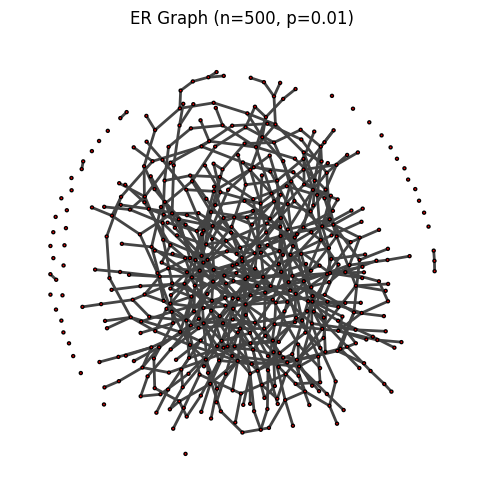

Connected: False | Nodes: 500 | Edges: 626 | Mean degree: 2.504


In [7]:
# Creating an ER graph and inspecting basic properties
np.random.seed(0)
g = ig.Graph.Erdos_Renyi(n=500, p=0.005, directed=False)

fig, ax = plt.subplots(figsize=(6, 6))
ig.plot(g, target=ax, vertex_size=3, vertex_label=None)
ax.set_title("ER Graph (n=500, p=0.01)")
plt.show()

print(f"Connected: {g.is_connected()} | Nodes: {g.vcount()} | Edges: {g.ecount()} | Mean degree: {np.mean(g.degree()):.3f}")

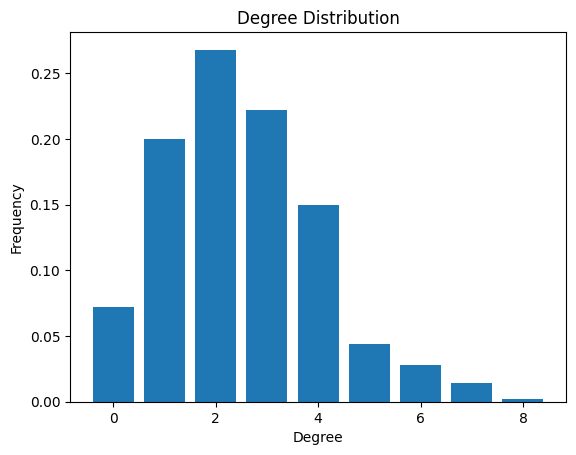

In [8]:
# Plotting degree distribution
deg = g.degree()
counts = Counter(deg)
k_vals = sorted(counts.keys())
freq = [counts[k] / g.vcount() for k in k_vals]

plt.bar(k_vals, freq)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")
plt.show()

In [9]:
# Extracting the Giant Connected Component (GCC)
components = g.components()
print("Component sizes:", sorted(components.sizes(), reverse=True))

gcc = components.giant()
print(f"GCC size: {gcc.vcount()}/{g.vcount()} | Diameter: {gcc.diameter()}")

Component sizes: [455, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
GCC size: 455/500 | Diameter: 16


### 1.2 Preferential Attachment Networks

Useful functions: `ig.Graph.Barabasi`, `g.community_fastgreedy()`, `g.modularity()`, `g.assortativity_degree()`, `ig.Graph.Degree_Sequence`

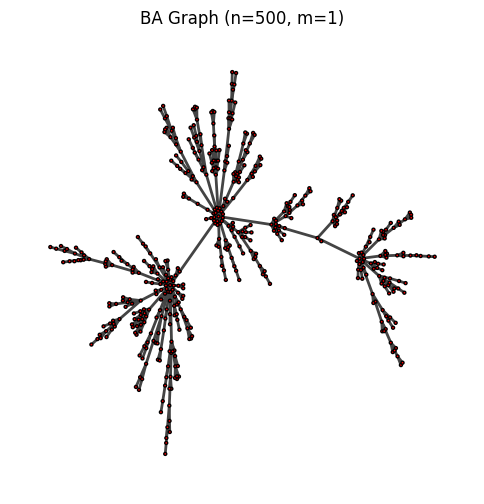

Connected: True | Nodes: 500 | Edges: 499 | Mean degree: 1.996


In [10]:
# Creating a BA graph
g_pa = ig.Graph.Barabasi(n=500, m=1, directed=False)

fig, ax = plt.subplots(figsize=(6, 6))
ig.plot(g_pa, target=ax, vertex_size=3, vertex_label=None)
ax.set_title("BA Graph (n=500, m=1)")
plt.show()

print(f"Connected: {g_pa.is_connected()} | Nodes: {g_pa.vcount()} | Edges: {g_pa.ecount()} | Mean degree: {np.mean(g_pa.degree()):.3f}")

In [11]:
# Community detection and modularity
comm = g_pa.community_fastgreedy()
membership = comm.as_clustering()
print(f"Modularity: {membership.modularity:.4f}")
print(f"Assortativity: {g_pa.assortativity_degree(directed=False):.4f}")

Modularity: 0.8978
Assortativity: -0.0852


Power law slope: -1.834


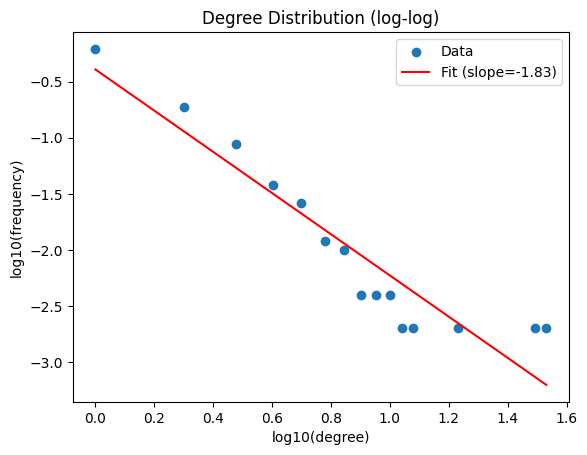

In [12]:
# Log-log degree distribution with linear regression
deg = g_pa.degree()
counts = Counter(deg)
k_vals = np.array(sorted(counts.keys()))
freq = np.array([counts[k] / g_pa.vcount() for k in k_vals])

# Remove degree 0 for log-log
mask = k_vals > 0
log_k = np.log10(k_vals[mask])
log_f = np.log10(freq[mask])

slope, intercept = np.polyfit(log_k, log_f, 1)
print(f"Power law slope: {slope:.3f}")

plt.scatter(log_k, log_f, label="Data")
plt.plot(log_k, slope * log_k + intercept, 'r-', label=f"Fit (slope={slope:.2f})")
plt.xlabel("log10(degree)")
plt.ylabel("log10(frequency)")
plt.title("Degree Distribution (log-log)")
plt.legend()
plt.show()

### 1.3 Modified Preferential Attachment (Age-Penalized)

Connection probability: $P[i] \sim (c \cdot k_i^\alpha + a)(d \cdot l_i^\beta + b)$

Note: `python-igraph` does not directly expose `sample_pa_age` from the C core. Below is a manual implementation. For this question, we recommend using the R version of the helper code, which calls the native `sample_pa_age` function directly. The Python implementation below is not guaranteed to produce identical results.

In [13]:
def sample_pa_age(n, m=1, alpha=1, beta=-1, a=1, b=0, c=1, d=1):
    """Generate a preferential attachment network with aging.
    P[i] ~ (c * k_i^alpha + a) * (d * l_i^beta + b)
    where k_i = degree, l_i = age of vertex i.
    """
    g = ig.Graph(n=1, directed=False)
    for t in range(1, n):
        degrees = np.array(g.degree(), dtype=float)
        ages = np.array([t - i for i in range(t)], dtype=float)
        probs = (c * np.power(degrees, alpha) + a) * (d * np.power(ages, beta) + b)
        probs = np.maximum(probs, 0)
        if probs.sum() == 0:
            probs = np.ones(t)
        probs /= probs.sum()
        targets = np.random.choice(t, size=min(m, t), replace=False, p=probs)
        g.add_vertices(1)
        g.add_edges([(t, int(tgt)) for tgt in targets])
    return g

# Demo
np.random.seed(0)
g_age = sample_pa_age(500, m=1, alpha=1, beta=-1, a=1, b=0, c=1, d=1)
print(f"Nodes: {g_age.vcount()} | Edges: {g_age.ecount()}")

Nodes: 500 | Edges: 499


---
## Part 2: Random Walk on Networks

### Transition Matrix

In [14]:
def create_transition_matrix(g):
    """Build a row-stochastic transition matrix. Isolated nodes get a self-loop."""
    adj = np.array(g.get_adjacency().data, dtype=float)
    row_sums = adj.sum(axis=1)
    # Handle isolated nodes by adding self-loops
    isolated = np.where(row_sums == 0)[0]
    adj[isolated, isolated] = 1.0
    row_sums = adj.sum(axis=1)
    return adj / row_sums[:, np.newaxis]

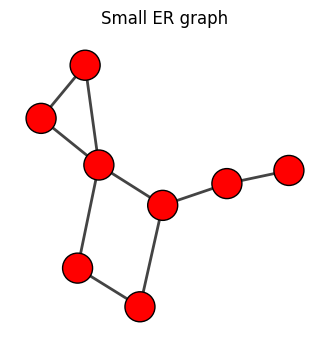

Transition matrix:
[[0.    0.5   0.    0.    0.    0.    0.    0.5  ]
 [0.25  0.    0.    0.25  0.    0.    0.25  0.25 ]
 [0.    0.    0.    0.5   0.    0.    0.5   0.   ]
 [0.    0.5   0.5   0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.333 0.333 0.    0.333 0.    0.    0.   ]
 [0.5   0.5   0.    0.    0.    0.    0.    0.   ]]


In [15]:
# Demo on a small undirected graph
np.random.seed(0)
g_small = ig.Graph.Erdos_Renyi(n=8, p=0.3, directed=False)

fig, ax = plt.subplots(figsize=(4, 4))
ig.plot(g_small, target=ax)
ax.set_title("Small ER graph")
plt.show()

print("Transition matrix:")
print(np.round(create_transition_matrix(g_small), 3))

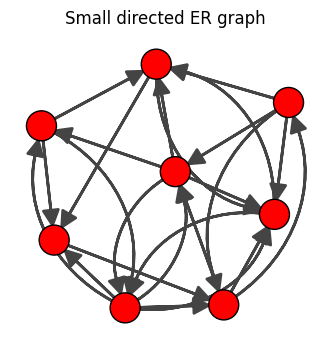

Transition matrix:
[[0.    0.333 0.    0.    0.333 0.333 0.    0.   ]
 [0.25  0.    0.    0.    0.25  0.25  0.25  0.   ]
 [0.2   0.    0.    0.2   0.2   0.2   0.    0.2  ]
 [1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.5   0.    0.    0.    0.5   0.   ]
 [0.    0.    0.25  0.    0.25  0.    0.25  0.25 ]
 [0.    0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.333 0.333 0.    0.    0.333 0.   ]]


In [16]:
# Also works for directed graphs
np.random.seed(1)
g_dir = ig.Graph.Erdos_Renyi(n=8, p=0.4, directed=True)

fig, ax = plt.subplots(figsize=(4, 4))
ig.plot(g_dir, target=ax)
ax.set_title("Small directed ER graph")
plt.show()

print("Transition matrix:")
print(np.round(create_transition_matrix(g_dir), 3))

### Random Walk

A single `random_walk` function that supports:
- Basic walk (no teleportation) — for Q2.1, Q2.2
- Uniform teleportation — for Q2.3 (standard PageRank)
- Weighted teleportation — for Q2.4 (personalized PageRank)
- Path tracking — for measuring distance from start over time

In [17]:
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    """
    Random walk on a graph.
      teleport_prob:    probability of teleporting at each step (0 = no teleportation)
      teleport_weights: array of teleportation target probabilities (None = uniform)
      track_path:       if True, return full path; otherwise return final node
    """
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

In [18]:
# Demo: basic random walk
np.random.seed(1)
path = random_walk(g_small, num_steps=15, start_node=0, track_path=True)
print("Path:", path)

Path: [0, 1, 6, 1, 3, 1, 0, 1, 3, 1, 6, 2, 6, 1, 7, 0]


### 2.3 PageRank: Merging Two Directed PA Networks

To avoid "black hole" nodes (no outgoing edges), we merge two directed PA networks by shuffling the second network's node indices and adding its edges to the first.

In [19]:
def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    # Get edge list of second network and shuffle node indices
    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

# Demo
np.random.seed(0)
g_pr = create_merged_pa_network(900, 4)
print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

Nodes: 900 | Edges: 7180
